Bibliotecas

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, InputLayer
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

Geração de dados sintéticos

In [7]:
# 1. Dados sintéticos
n_samples = 1000
n_epochs = 50

sensor_raw = np.linspace(0, 1, n_samples)

# 2. Função "verdadeira" do sensor calibrado
def true_sensor_calibrated(x):
    return x**1.05 - 0.02*np.sin(5*x)

# 3. Ruído inicial grande para simular leituras instáveis
noise_level_initial = 0.05

# 4. Função para gerar leituras com ruído decrescente ao longo do treinamento
def generate_sensor_data(epoch):
    noise_factor = noise_level_initial * np.exp(-0.1 * epoch)
    noise = np.random.normal(0, noise_factor, size = sensor_raw.shape)
    return true_sensor_calibrated(sensor_raw) + noise

Criação do modelo CNN para treinamento

In [8]:
# 5. Criar CNN para calibração
model = Sequential([
    InputLayer(input_shape = (1,1)),
    Conv1D(16, kernel_size = 3, activation='relu', padding ='same'),
    Conv1D(16, kernel_size = 3, activation='relu', padding = 'same'),
    Flatten(),
    Dense(32, activation = 'relu'),
    Dense(1)
])

model.compile(optimizer = 'adam', loss = 'mse')

# 6. Preparar dados para CNN (shape [n_samples, 1, 1])
X = sensor_raw.reshape(-1,1,1)

# 7. Treinamento incremental e coleta de métricas
mean_intensities = []
num_anomalies = []
mae_list = []
r2_list = []

# 8. Inicializar y com valores ruidosos grandes
y_current = generate_sensor_data(0).reshape(-1,1)

for epoch in range(1, n_epochs+1):
    # Treinar CNN por 1 época
    model.fit(X, y_current, epochs = 1, verbose = 0)
    
    # Previsão atual
    y_pred = model.predict(X, verbose = 0).flatten()
    
    # Métricas
    mae_list.append(mean_absolute_error(true_sensor_calibrated(sensor_raw), y_pred))
    r2_list.append(r2_score(true_sensor_calibrated(sensor_raw), y_pred))
    
    # Simular evolução da intensidade e anomalias
    mean_intensity = np.mean(y_pred)
    anomalies = np.sum(np.abs(y_pred - sensor_raw) > 0.05)  # diferença >5% considera anomalia
    
    mean_intensities.append(mean_intensity)
    num_anomalies.append(anomalies)
    
    # Atualizar y_current para próxima época com ruído decrescente
    y_current = generate_sensor_data(epoch).reshape(-1,1)

# 9. Última previsão para curva de calibração
sensor_pred_final = model.predict(X, verbose = 1).flatten()

/home/pojucan/codigos/modelo-cnn-sensores/.venv/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Média da intensidade

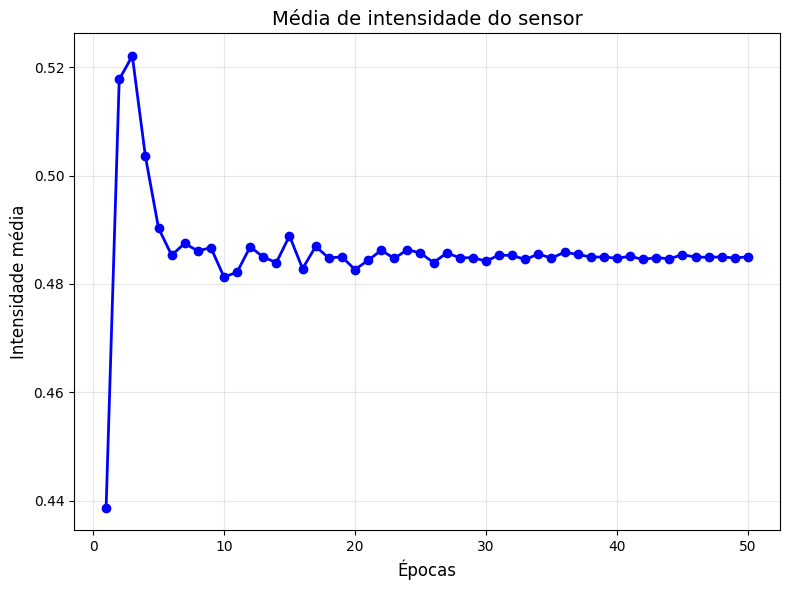

In [9]:
# 10. Gerar e salvar figuras separadas

# Figura 1: Média de intensidade
plt.figure(figsize = (8, 6))
plt.plot(range(1, n_epochs+1), mean_intensities, marker = 'o', color = 'blue', linewidth=2)
plt.title("Média de intensidade do sensor", fontsize = 14)
plt.xlabel("Épocas", fontsize = 12)
plt.ylabel("Intensidade média", fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.savefig('media_intensidade_sensor.png', dpi = 300, bbox_inches = 'tight')
plt.savefig('media_intensidade_sensor.pdf', bbox_inches = 'tight')
plt.show()

Número de anomalias

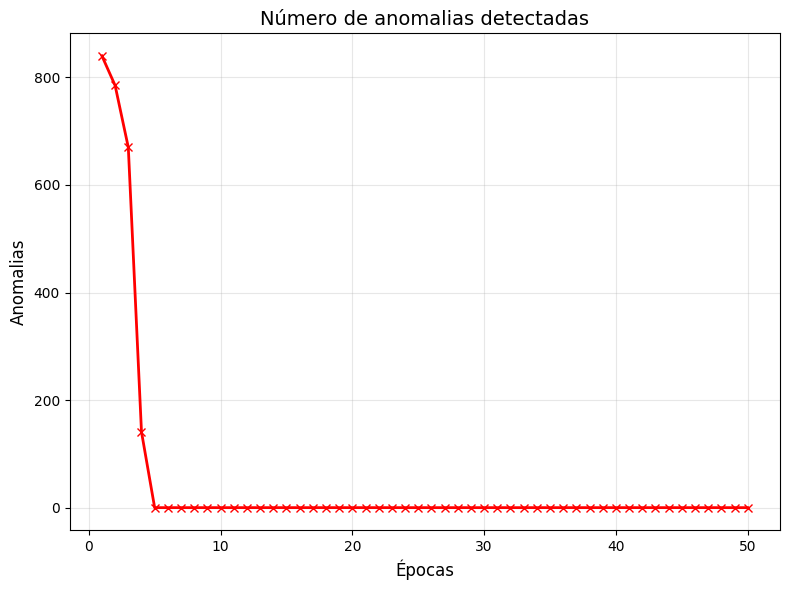

In [10]:
# Figura 2: Número de anomalias
plt.figure(figsize = (8, 6))
plt.plot(range(1, n_epochs+1), num_anomalies, marker = 'x', color = 'red', linewidth = 2)
plt.title("Número de anomalias detectadas", fontsize = 14)
plt.xlabel("Épocas", fontsize = 12)
plt.ylabel("Anomalias", fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.savefig('anomalias_detectadas.png', dpi = 300, bbox_inches = 'tight') # Desabilite para salvar as anomalias
plt.savefig('anomalias_detectadas.pdf', bbox_inches = 'tight') # Desabilite para salvar as anomalias
plt.show()

Exibição da curva de calibração

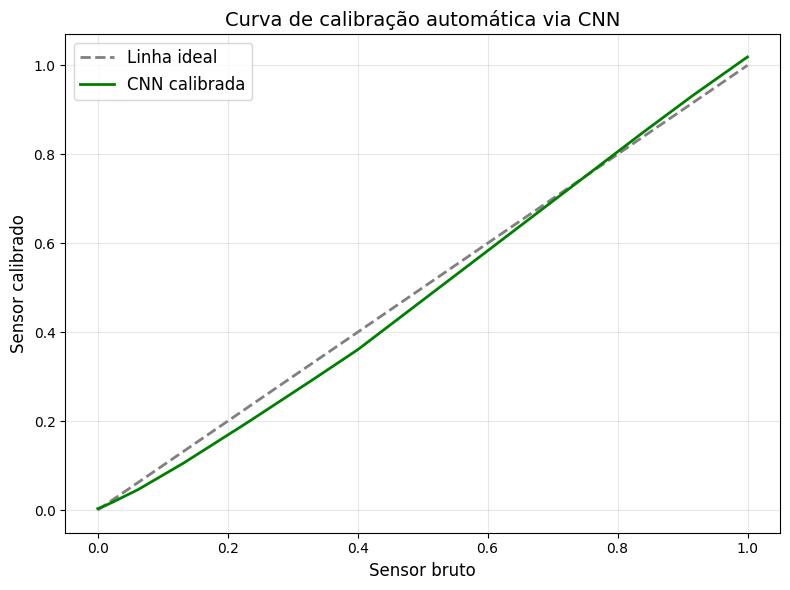

In [11]:
# Figura 3: Curva de calibração
plt.figure(figsize = (8, 6))
plt.plot(sensor_raw, sensor_raw, '--', label = "Linha ideal", color = 'gray', linewidth = 2)
plt.plot(sensor_raw, sensor_pred_final, label = "CNN calibrada", color = 'green', linewidth = 2)
plt.title("Curva de calibração automática via CNN", fontsize = 14)
plt.xlabel("Sensor bruto", fontsize = 12)
plt.ylabel("Sensor calibrado", fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.savefig('curva_calibracao_cnn.png', dpi = 300, bbox_inches = 'tight') # Desabilite para salvar a calibração
plt.savefig('curva_calibracao_cnn.pdf', bbox_inches = 'tight') # Desabilite para salvar a calibração
plt.show()

Métricas de desempenho

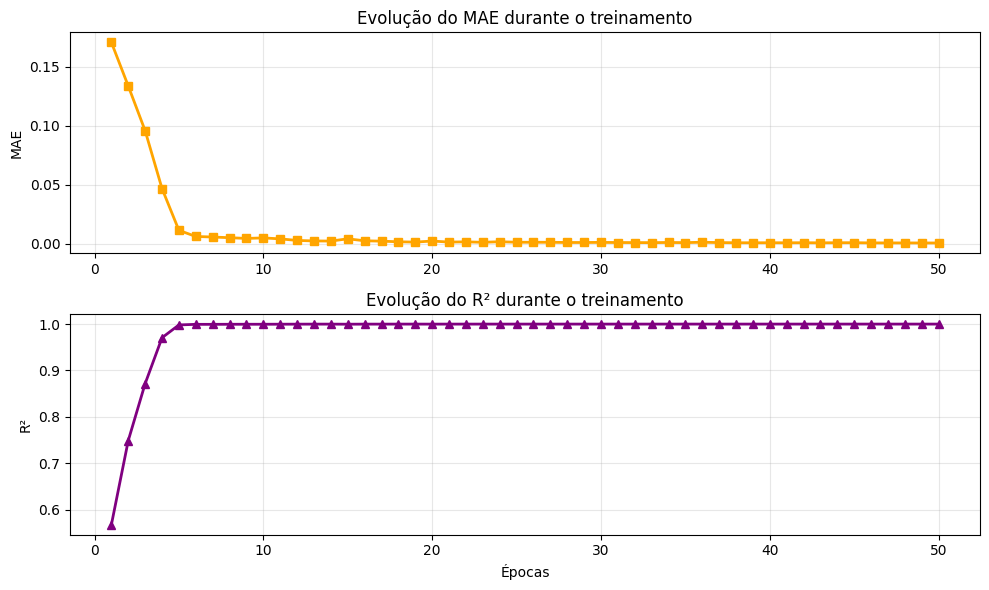

In [12]:
# Figura 4: Métricas de desempenho (MAE e R²)
plt.figure(figsize = (10, 6))
plt.subplot(2, 1, 1)
plt.plot(range(1, n_epochs+1), mae_list, marker = 's', color = 'orange', linewidth = 2)
plt.title("Evolução do MAE durante o treinamento", fontsize = 12)
plt.ylabel("MAE", fontsize = 10)
plt.grid(True, alpha = 0.3)

plt.subplot(2, 1, 2)
plt.plot(range(1, n_epochs+1), r2_list, marker = '^', color = 'purple', linewidth = 2)
plt.title("Evolução do R² durante o treinamento", fontsize = 12)
plt.xlabel("Épocas", fontsize = 10)
plt.ylabel("R²", fontsize = 10)
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.savefig('metricas_treinamento.png', dpi = 300, bbox_inches = 'tight') # Desabilite para salvar as métricas
plt.savefig('metricas_treinamento.pdf', bbox_inches = 'tight') # Desabilite para salvar as métricas
plt.show()

Resumo das métricas finais

In [13]:
# 11. Exibir métricas finais:
print(f"MAE final: {mae_list[-1]:.4f}")
print(f"R² final: {r2_list[-1]:.4f}")

# # Opcional:
# print("\nFiguras salvas como:")
# print("- media_intensidade_sensor.png/.pdf")
# print("- anomalias_detectadas.png/.pdf") 
# print("- curva_calibracao_cnn.png/.pdf")
# print("- metricas_treinamento.png/.pdf")

MAE final: 0.0008
R² final: 1.0000
